<div style="text-align:center; border-radius:15px 50px; padding:22px; color:white; background-color:#000080; font-family:Pacifico">
<h1 style="color:white; margin:0; font-size:230%">Air Quality Analysis — Modular Edition</h1>
<h3 style="color:#c9d4ff; margin-top:10px; font-family:Arial">Each course concept as a standalone, importable .py module &nbsp;|&nbsp; PRG-330 Final Project</h3>
<p style="color:#ffffff; font-family:Arial; font-size:110%; margin-top:16px; margin-bottom:0">
<b>Team:</b> &nbsp; Aishmita &nbsp;&middot;&nbsp; Aaska &nbsp;&middot;&nbsp; Anupam
</p>
</div>

## How this notebook is organized

Every course module below is a **real, standalone Python file** (`m00_load_data.py` through
`m09_conclusion.py`), not just a notebook section. For each module:

1. A `%%writefile` cell writes that module's source code to disk as its own `.py` file.
2. An import cell loads the file that was just written and calls its functions, so the
   results still show up inline here.

Every one of those `.py` files can also be run on its own from a terminal (`python m01_variables.py`)
or imported from anywhere else — this notebook is an *orchestrator*, not a container. **No
module uses hand-typed or synthetic data.** Every variable, sample, and table is pulled directly
from the real `Air_Quality.csv` (52,704 hourly rows, 6 cities, 2024) by filtering, grouping, or
sampling the actual file — never typed in by hand.

| File | Course concept |
| :--- | :--- |
| `m00_load_data.py` | shared CSV loader, reused by every later module |
| `m01_variables.py` | variables & data types (one real row, pulled by filter) |
| `m02_operators.py` | arithmetic / comparison / logical / assignment operators |
| `m03_conditions.py` | `if` / `elif` / `else` AQI classification |
| `m04_loops.py` | `for`, `for`-with-condition, and `while` loops |
| `m05_functions.py` | reusable functions with parameters, return values, and defaults |
| `m06_file_io.py` | raw `open()`-based file input and output |
| `m07_pandas_numpy.py` | full Pandas + NumPy analysis on all 52,704 rows |
| `m08_visualization.py` | Matplotlib charts built from Module 7's output |
| `m09_conclusion.py` | findings generated live from the real numbers Module 7 produced |


In [1]:
# make sure this notebook's own folder is searched for the modules we are about to write,
# and give ourselves a helper that re-imports a module after its %%writefile cell re-writes it
# (plain `import` would otherwise return the already-cached, possibly stale, version)
import sys, os, importlib

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())


def fresh_import(module_name):
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])
        return sys.modules[module_name]
    return importlib.import_module(module_name)

## Module 0: shared data loader

Every other module imports this one to load `Air_Quality.csv`. Keeping the loading logic in
one place means every module works from an identical copy of the real data.

In [2]:
%%writefile m00_load_data.py
"""Module 0: shared data loader - reused by every other module in this project.

Every function in this project reads from the real Air_Quality.csv file. Nothing in
this module (or any module that imports it) is hand-typed or synthetic data.
"""
import pandas as pd

DATA_PATH = "Air_Quality.csv"


def load_data(path=DATA_PATH):
    """Load the raw Air Quality CSV into a DataFrame, exactly as recorded."""
    return pd.read_csv(path)


def load_data_with_month(path=DATA_PATH):
    """Load the CSV, parse Date into a real datetime, and add a Month column."""
    df = load_data(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df["Month"] = df["Date"].dt.month
    return df


if __name__ == "__main__":
    df = load_data()
    print("Loaded", df.shape[0], "rows and", df.shape[1], "columns from", DATA_PATH)
    print(df.head())


Overwriting m00_load_data.py


In [3]:
m00 = fresh_import("m00_load_data")

df_raw = m00.load_data()
print("shape:", df_raw.shape)
df_raw.head()

shape: (52704, 10)


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000


## Module 1: variables and data types

**Course concepts:** variables, `str`, `float`, `bool`, `type()`.

Instead of typing in a sample record, `get_worst_hour()` filters the real dataset for the row
with the highest AQI — Python decides which row that is, not us.

In [4]:
%%writefile m01_variables.py
"""Module 1: variables and data types - built from real rows of the dataset.

We never hand-type a sample record. The "worst" and "best" hours below are found by
filtering the real dataset (idxmax / idxmin on the real AQI column), not invented.
"""
from m00_load_data import load_data


def get_worst_hour(df):
    """Return the single real row with the highest AQI in the whole dataset."""
    worst_idx = df["AQI"].idxmax()
    return df.loc[worst_idx].to_dict()


def get_best_hour(df):
    """Return the single real row with the lowest AQI in the whole dataset."""
    best_idx = df["AQI"].idxmin()
    return df.loc[best_idx].to_dict()


def unpack_record(record):
    """Pull a record dict apart into individual named variables, showing each Python type."""
    record_date = str(record["Date"])          # str
    record_city = str(record["City"])          # str
    co_level = float(record["CO"])              # float
    co2_level = record["CO2"]                   # float (may be NaN)
    no2_level = float(record["NO2"])             # float
    so2_level = float(record["SO2"])             # float
    o3_level = float(record["O3"])               # float
    pm25_level = float(record["PM2.5"])          # float
    pm10_level = float(record["PM10"])           # float
    aqi_value = float(record["AQI"])             # float
    is_high_pollution_hour = aqi_value > 100     # bool

    return {
        "record_date": record_date,
        "record_city": record_city,
        "co_level": co_level,
        "co2_level": co2_level,
        "no2_level": no2_level,
        "so2_level": so2_level,
        "o3_level": o3_level,
        "pm25_level": pm25_level,
        "pm10_level": pm10_level,
        "aqi_value": aqi_value,
        "is_high_pollution_hour": is_high_pollution_hour,
    }


if __name__ == "__main__":
    df = load_data()
    worst = unpack_record(get_worst_hour(df))
    print("Worst recorded hour in the whole dataset:")
    for name, value in worst.items():
        print(f"  {name:22s} = {value!r:25}  ({type(value).__name__})")


Overwriting m01_variables.py


In [5]:
m01 = fresh_import("m01_variables")

worst_hour = m01.unpack_record(m01.get_worst_hour(df_raw))
for name, value in worst_hour.items():
    print(f"{name:22s} = {value!r:25}  ({type(value).__name__})")

record_date            = '2024-08-18 04:00:00+00:00'  (str)
record_city            = 'Dubai'                    (str)
co_level               = 229.0                      (float)
co2_level              = nan                        (float)
no2_level              = 21.0                       (float)
so2_level              = 10.8                       (float)
o3_level               = 51.0                       (float)
pm25_level             = 65.9                       (float)
pm10_level             = 391.2                      (float)
aqi_value              = 196.63333                  (float)
is_high_pollution_hour = True                       (bool)


## Module 2: operators

**Course concepts:** arithmetic, comparison, logical, and assignment operators.

`get_best_hour()` filters the same real dataset for the lowest AQI, giving us a genuine
contrast to the worst hour from Module 1 — both rows come straight out of `Air_Quality.csv`.

In [6]:
%%writefile m02_operators.py
"""Module 2: operators - arithmetic, comparison, logical and assignment, on two real rows."""
from m00_load_data import load_data
from m01_variables import get_worst_hour, get_best_hour, unpack_record


def arithmetic_demo(worst, best):
    pm_total_worst = worst["pm25_level"] + worst["pm10_level"]        # addition
    pm_difference_worst = worst["pm10_level"] - worst["pm25_level"]   # subtraction
    aqi_doubled_best = best["aqi_value"] * 2                           # multiplication
    aqi_halved_worst = worst["aqi_value"] / 2                          # division
    aqi_mod_worst = int(worst["aqi_value"]) % 50                       # modulus
    return {
        "pm_total_worst": pm_total_worst,
        "pm_difference_worst": pm_difference_worst,
        "aqi_doubled_best": aqi_doubled_best,
        "aqi_halved_worst": aqi_halved_worst,
        "aqi_mod_worst": aqi_mod_worst,
    }


def comparison_demo(worst, best):
    return {
        "worst_aqi_gt_best_aqi": worst["aqi_value"] > best["aqi_value"],
        "worst_city_ne_best_city": worst["record_city"] != best["record_city"],
        "worst_pm10_ge_100": worst["pm10_level"] >= 100,
    }


def logical_demo(worst):
    pm25_high = worst["pm25_level"] > 35
    pm10_high = worst["pm10_level"] > 150
    return {
        "both_high_and": pm25_high and pm10_high,
        "either_high_or": pm25_high or pm10_high,
        "not_calm": not (worst["aqi_value"] <= 50),
    }


def assignment_demo(worst, best):
    running_total = 0
    running_total += worst["aqi_value"]
    running_total += best["aqi_value"]
    running_total_scaled = running_total
    running_total_scaled *= 10
    return running_total, running_total_scaled


if __name__ == "__main__":
    df = load_data()
    worst = unpack_record(get_worst_hour(df))
    best = unpack_record(get_best_hour(df))
    print("Worst hour:", worst["record_city"], worst["record_date"], "AQI =", worst["aqi_value"])
    print("Best hour :", best["record_city"], best["record_date"], "AQI =", best["aqi_value"])
    print()
    print("Arithmetic:", arithmetic_demo(worst, best))
    print("Comparison:", comparison_demo(worst, best))
    print("Logical   :", logical_demo(worst))
    print("Assignment:", assignment_demo(worst, best))


Overwriting m02_operators.py


In [7]:
m02 = fresh_import("m02_operators")

best_hour = m02.unpack_record(m02.get_best_hour(df_raw))
print("Worst hour:", worst_hour["record_city"], worst_hour["record_date"], "AQI =", worst_hour["aqi_value"])
print("Best hour :", best_hour["record_city"], best_hour["record_date"], "AQI =", best_hour["aqi_value"])
print()
print("Arithmetic :", m02.arithmetic_demo(worst_hour, best_hour))
print("Comparison :", m02.comparison_demo(worst_hour, best_hour))
print("Logical    :", m02.logical_demo(worst_hour))
print("Assignment :", m02.assignment_demo(worst_hour, best_hour))

Worst hour: Dubai 2024-08-18 04:00:00+00:00 AQI = 196.63333
Best hour : Brasilia 2024-02-21 01:00:00+00:00 AQI = 4.45

Arithmetic : {'pm_total_worst': 457.1, 'pm_difference_worst': 325.29999999999995, 'aqi_doubled_best': 8.9, 'aqi_halved_worst': 98.316665, 'aqi_mod_worst': 46}
Comparison : {'worst_aqi_gt_best_aqi': True, 'worst_city_ne_best_city': True, 'worst_pm10_ge_100': True}
Logical    : {'both_high_and': True, 'either_high_or': True, 'not_calm': True}
Assignment : (201.08333, 2010.8332999999998)


## Module 3: conditional statements

**Course concepts:** `if` / `elif` / `else`.

`classify_aqi()` sorts any AQI value into one of six EPA-style categories. We run it on the
same real worst/best rows from Modules 1 and 2.

In [8]:
%%writefile m03_conditions.py
"""Module 3: conditional statements - if / elif / else, applied to real AQI values."""
from m00_load_data import load_data
from m01_variables import get_worst_hour, get_best_hour, unpack_record


def classify_aqi(aqi):
    """Return the EPA-style category name for a given AQI value."""
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"


def high_pollution_condition(pm25, pm10):
    """True only when both PM2.5 and PM10 are elevated at the same time."""
    if pm25 > 35 and pm10 > 150:
        return True
    else:
        return False


if __name__ == "__main__":
    df = load_data()
    worst = unpack_record(get_worst_hour(df))
    best = unpack_record(get_best_hour(df))
    for label, record in [("Worst hour", worst), ("Best hour", best)]:
        category = classify_aqi(record["aqi_value"])
        flagged = high_pollution_condition(record["pm25_level"], record["pm10_level"])
        print(f"{label}: {record['record_city']} {record['record_date']} "
              f"AQI={record['aqi_value']:.1f} -> {category}  (high pollution: {flagged})")


Overwriting m03_conditions.py


In [9]:
m03 = fresh_import("m03_conditions")

for label, record in [("Worst hour", worst_hour), ("Best hour", best_hour)]:
    category = m03.classify_aqi(record["aqi_value"])
    flagged = m03.high_pollution_condition(record["pm25_level"], record["pm10_level"])
    print(f"{label}: {record['record_city']} {record['record_date']} "
          f"AQI={record['aqi_value']:.1f} -> {category}  (high pollution: {flagged})")

Worst hour: Dubai 2024-08-18 04:00:00+00:00 AQI=196.6 -> Unhealthy  (high pollution: True)
Best hour: Brasilia 2024-02-21 01:00:00+00:00 AQI=4.5 -> Good  (high pollution: False)


## Module 4: loops

**Course concepts:** `for` loops, a `for` loop with a condition inside, and a `while` loop.

`get_sample_rows()` filters the real dataset for two real timestamps across all six cities —
a genuine 12-row sample taken directly from `Air_Quality.csv`, not typed in by hand.

In [10]:
%%writefile m04_loops.py
"""Module 4: loops - for, for-with-condition, and while, over a real 12-row sample.

The 12-row sample is pulled by filtering the real dataset for two real timestamps
(one per city, at each timestamp) -- it is never hand-typed.
"""
import pandas as pd
from m00_load_data import load_data

SAMPLE_DATES = ["2024-02-11 16:00:00+00:00", "2024-12-29 22:00:00+00:00"]


def get_sample_rows(df):
    """Pull the same real hour from every city, for two real dates: a 12-row sample
    selected from the actual dataset by filtering, not typed in by hand."""
    mask = df["Date"].astype(str).isin(SAMPLE_DATES)
    sample = df[mask].sort_values(["Date", "City"]).reset_index(drop=True)
    return sample.to_dict("records")


def total_and_average_aqi(records):
    """A basic for loop: add up AQI and count records by hand."""
    total = 0.0
    count = 0
    for rec in records:
        total += rec["AQI"]
        count += 1
    average = total / count if count else 0
    return total, average


def flag_high_aqi(records, threshold=50):
    """A for loop with a condition inside: collect every record above the threshold."""
    flagged = []
    for rec in records:
        if rec["AQI"] > threshold:
            flagged.append(rec)
    return flagged


def find_worst_without_max(records):
    """Find the worst record using a loop and a comparison, without calling max()."""
    worst = records[0]
    for rec in records:
        if rec["AQI"] > worst["AQI"]:
            worst = rec
    return worst


def first_missing_co2(records):
    """A while loop: stop as soon as the first record with a missing CO2 value is found."""
    index = 0
    found = False
    while index < len(records) and not found:
        if pd.isna(records[index]["CO2"]):
            found = True
        else:
            index += 1
    return records[index] if found else None


if __name__ == "__main__":
    df = load_data()
    sample = get_sample_rows(df)
    print("Sample size:", len(sample))

    total, average = total_and_average_aqi(sample)
    print("Total AQI:", round(total, 2), " Average AQI:", round(average, 2))

    high = flag_high_aqi(sample)
    print("High-AQI (>50) records:", len(high), "out of", len(sample))

    worst = find_worst_without_max(sample)
    print("Worst sample record:", worst["City"], worst["Date"], "AQI =", worst["AQI"])

    first_missing = first_missing_co2(sample)
    if first_missing:
        print("First record with missing CO2:", first_missing["City"], first_missing["Date"])


Overwriting m04_loops.py


In [11]:
m04 = fresh_import("m04_loops")

sample = m04.get_sample_rows(df_raw)
print("Sample size:", len(sample))

total, average = m04.total_and_average_aqi(sample)
print("Total AQI:", round(total, 2), " Average AQI:", round(average, 2))

high = m04.flag_high_aqi(sample)
print("High-AQI (>50) records:", len(high), "out of", len(sample))

worst_sample_record = m04.find_worst_without_max(sample)
print("Worst sample record (loop, no max()):", worst_sample_record["City"], worst_sample_record["Date"])

first_missing = m04.first_missing_co2(sample)
print("First sample record with missing CO2:", first_missing["City"], first_missing["Date"])

Sample size: 12
Total AQI: 499.19  Average AQI: 41.6
High-AQI (>50) records: 4 out of 12
Worst sample record (loop, no max()): Dubai 2024-02-11 16:00:00+00:00
First sample record with missing CO2: Brasilia 2024-02-11 16:00:00+00:00


## Module 5: functions

**Course concepts:** function definitions, parameters, return values, and default parameter
values.

`calculate_total()` / `calculate_average()` are called on every real AQI reading for each real
city — not a sample this time, the full per-city column.

In [12]:
%%writefile m05_functions.py
"""Module 5: functions - reusable total/average/condition helpers, called on real data."""
from m00_load_data import load_data


def calculate_total(values):
    """Add up a list of numbers using a loop."""
    total = 0
    for v in values:
        total += v
    return total


def calculate_average(values):
    """Return the average of a list of numbers."""
    if len(values) == 0:
        return 0
    return calculate_total(values) / len(values)


def is_high_pollution(pm25, pm10, pm25_limit=35, pm10_limit=150):
    """Return True when both PM2.5 and PM10 exceed the given limits."""
    return pm25 > pm25_limit and pm10 > pm10_limit


def summarize_city_aqi(df, city):
    """Use calculate_total / calculate_average on every real AQI reading for one real city."""
    values = df.loc[df["City"] == city, "AQI"].tolist()
    return {
        "city": city,
        "count": len(values),
        "total": round(calculate_total(values), 2),
        "average": round(calculate_average(values), 2),
    }


if __name__ == "__main__":
    df = load_data()
    for city in sorted(df["City"].unique()):
        print(summarize_city_aqi(df, city))

    worst_row = df.loc[df["AQI"].idxmax()]
    print("High pollution at the dataset's worst hour:",
          is_high_pollution(worst_row["PM2.5"], worst_row["PM10"]))


Overwriting m05_functions.py


In [13]:
m05 = fresh_import("m05_functions")

for city in sorted(df_raw["City"].unique()):
    print(m05.summarize_city_aqi(df_raw, city))

print()
print("High pollution at the dataset's worst hour:",
      m05.is_high_pollution(worst_hour["pm25_level"], worst_hour["pm10_level"]))

{'city': 'Brasilia', 'count': 8784, 'total': 217398.36, 'average': 24.75}
{'city': 'Cairo', 'count': 8784, 'total': 461069.92, 'average': 52.49}
{'city': 'Dubai', 'count': 8784, 'total': 747638.94, 'average': 85.11}
{'city': 'London', 'count': 8784, 'total': 238021.91, 'average': 27.1}


{'city': 'New York', 'count': 8784, 'total': 288802.52, 'average': 32.88}
{'city': 'Sydney', 'count': 8784, 'total': 226343.9, 'average': 25.77}

High pollution at the dataset's worst hour: True


## Module 6: file input/output

**Course concept:** raw `open()`-based reading and writing — no Pandas in this module at all.

We read the real CSV file byte-by-line and write our own summary report straight to disk, then
read that file back to prove it saved correctly.

In [14]:
%%writefile m06_file_io.py
"""Module 6: file input/output - raw open() reading and writing, no Pandas at all."""

DATA_PATH = "Air_Quality.csv"
SUMMARY_PATH = "file_io_summary.txt"


def peek_header_and_first_row(path=DATA_PATH):
    """Read just the header line and the first data line of the real CSV."""
    with open(path, "r") as file:
        header_line = file.readline()
        first_data_line = file.readline()
    return header_line.strip(), first_data_line.strip()


def compute_aqi_stats_from_csv(path=DATA_PATH, max_lines=2000, aqi_column_index=9):
    """Read up to max_lines real data rows and total/average the AQI column by hand."""
    line_count = 0
    total_aqi = 0.0
    with open(path, "r") as file:
        file.readline()  # skip header
        for line in file:
            if line_count >= max_lines:
                break
            fields = line.strip().split(",")
            total_aqi += float(fields[aqi_column_index])
            line_count += 1
    average_aqi = total_aqi / line_count if line_count else 0
    return line_count, total_aqi, average_aqi


def write_summary(path, line_count, total_aqi, average_aqi):
    """Write a short summary report, built entirely from numbers computed above."""
    with open(path, "w") as out_file:
        out_file.write("Air Quality Project -- File I/O Summary\n")
        out_file.write("========================================\n")
        out_file.write(f"Lines read directly from CSV: {line_count}\n")
        out_file.write(f"Total AQI of those rows: {round(total_aqi, 2)}\n")
        out_file.write(f"Average AQI of those rows: {round(average_aqi, 2)}\n")


def read_summary(path):
    """Read the summary file back, to prove it saved correctly."""
    with open(path, "r") as in_file:
        return in_file.read()


if __name__ == "__main__":
    header, first_row = peek_header_and_first_row()
    print("Header:", header)
    print("First row:", first_row)

    line_count, total_aqi, average_aqi = compute_aqi_stats_from_csv()
    print("Rows read:", line_count, " Average AQI:", round(average_aqi, 2))

    write_summary(SUMMARY_PATH, line_count, total_aqi, average_aqi)
    print()
    print(read_summary(SUMMARY_PATH))


Overwriting m06_file_io.py


In [15]:
m06 = fresh_import("m06_file_io")

header, first_row = m06.peek_header_and_first_row()
print("Header   :", header)
print("First row:", first_row)

line_count, total_aqi, average_aqi = m06.compute_aqi_stats_from_csv()
print("Rows read:", line_count, " Average AQI:", round(average_aqi, 2))

m06.write_summary(m06.SUMMARY_PATH, line_count, total_aqi, average_aqi)
print()
print(m06.read_summary(m06.SUMMARY_PATH))

Header   : Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
First row: 2024-01-01 00:00:00+00:00,Brasilia,323.0,,23.8,2.8,42.0,12.0,17.1,16.8
Rows read: 2000  Average AQI: 20.38

Air Quality Project -- File I/O Summary
Lines read directly from CSV: 2000
Total AQI of those rows: 40763.12
Average AQI of those rows: 20.38



## Module 7: Pandas + NumPy analysis

**Course concepts:** `groupby()`, aggregation, filtering, correlation (Pandas); arrays,
percentiles, IQR, boolean comparisons, `corrcoef()` (NumPy).

This is the full analysis on all 52,704 real rows: cleaning (parsing `Date`, flagging high
pollution, classifying every hour), then every table the rest of this project depends on.

In [16]:
%%writefile m07_pandas_numpy.py
"""Module 7: Pandas + NumPy analysis - cleaning and the full 52,704-row analysis.

This is the biggest module because, in the course material this project follows,
data cleaning and the Pandas/NumPy analysis are taught together as one unit. Every
number here comes from the real, full dataset -- nothing is sampled or invented.
"""
import numpy as np
import pandas as pd
from m00_load_data import load_data_with_month

CLEANED_PATH = "air_quality_cleaned_data.csv"


def missing_value_summary(df):
    """Count and percentage of missing values in every column."""
    counts = df.isnull().sum()
    percent = (counts / len(df) * 100).round(2)
    return pd.DataFrame({"missing_count": counts, "missing_percent": percent})


def co2_availability_by_month(df, city):
    """CO2 readings-present vs readings-total by month, for one real city."""
    city_df = df[df["City"] == city]
    present = city_df.groupby("Month")["CO2"].apply(lambda col: col.notnull().sum())
    total = city_df.groupby("Month")["CO2"].size()
    return pd.DataFrame({"readings_present": present, "readings_total": total})


def co2_usable_window(df):
    """When CO2 actually starts being recorded, and the city averages in that window."""
    available = df[df["CO2"].notnull()]
    return {
        "earliest": available["Date"].min(),
        "latest": available["Date"].max(),
        "rows": len(available),
        "percent_of_all": round(len(available) / len(df) * 100, 1),
        "avg_by_city": available.groupby("City")["CO2"].mean().round(1),
    }


def classify_aqi(aqi):
    """Same EPA-style classifier used in Module 3, reapplied here at full dataset scale."""
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"


def clean_data(df):
    """Add the AQI category, high-pollution flag, and PM total columns."""
    df = df.copy()
    df["AQI Category"] = df["AQI"].apply(classify_aqi)
    df["High Pollution"] = (df["PM2.5"] > 35) & (df["PM10"] > 150)
    df["PM_Total"] = df["PM2.5"] + df["PM10"]
    return df


def save_cleaned(df, path=CLEANED_PATH):
    """File output: save the cleaned DataFrame as a reusable project output."""
    df.to_csv(path, index=False)
    return path


def city_summary(df):
    """Average pollutant levels and AQI by city, worst to best."""
    cols = ["CO", "NO2", "SO2", "O3", "PM2.5", "PM10", "AQI"]
    return df.groupby("City")[cols].mean().round(2).sort_values("AQI", ascending=False)


def monthly_summary(df):
    """Average AQI by month, across all six cities."""
    return df.groupby("Month")["AQI"].mean().round(2)


def top_high_aqi_hours(df, threshold=100, top_n=10):
    """Count of hours over the threshold, and the single worst top_n rows."""
    high = df[df["AQI"] > threshold]
    worst = high[["Date", "City", "AQI", "PM2.5", "PM10"]].sort_values("AQI", ascending=False).head(top_n)
    return len(high), worst


def pollutant_correlations(df):
    """Correlation of every pollutant with AQI, strongest first."""
    cols = ["CO", "NO2", "SO2", "O3", "PM2.5", "PM10", "AQI"]
    return df[cols].corr()["AQI"].drop("AQI").sort_values(ascending=False).round(3)


def numpy_array_stats(df):
    """Mean/min/max/std for key pollutants, computed with NumPy arrays."""
    stats = {}
    for col in ["AQI", "PM2.5", "PM10", "CO", "NO2", "SO2", "O3"]:
        arr = df[col].to_numpy(dtype=float)
        stats[col] = {
            "mean": float(np.mean(arr)),
            "min": float(np.min(arr)),
            "max": float(np.max(arr)),
            "std": float(np.std(arr)),
        }
    return stats


def aqi_quartiles(df):
    """Q1/median/Q3, IQR, and the 1.5xIQR upper threshold for AQI, via NumPy."""
    arr = df["AQI"].to_numpy(dtype=float)
    q1, q2, q3 = np.percentile(arr, [25, 50, 75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    above = int(np.sum(arr > upper))
    return {"q1": q1, "q2": q2, "q3": q3, "iqr": iqr, "upper_threshold": upper,
            "count_above": above, "total": int(arr.size)}


def threshold_counts(df):
    """Boolean-comparison counts on NumPy arrays for common pollution thresholds."""
    aqi = df["AQI"].to_numpy(dtype=float)
    pm25 = df["PM2.5"].to_numpy(dtype=float)
    pm10 = df["PM10"].to_numpy(dtype=float)
    return {
        "aqi_gt_100": int(np.sum(aqi > 100)),
        "pm25_gt_35": int(np.sum(pm25 > 35)),
        "pm10_gt_150": int(np.sum(pm10 > 150)),
    }


def numpy_corrcoef_check(df, column):
    """Independently re-verify a pandas correlation using np.corrcoef()."""
    a = df[column].to_numpy(dtype=float)
    b = df["AQI"].to_numpy(dtype=float)
    return float(np.corrcoef(a, b)[0, 1])


if __name__ == "__main__":
    df = load_data_with_month()
    print(missing_value_summary(df))
    print()

    df = clean_data(df)
    save_cleaned(df)
    print("Saved cleaned dataset to", CLEANED_PATH)
    print()

    print(city_summary(df))
    print()
    print(monthly_summary(df))
    print()
    print(pollutant_correlations(df))


Overwriting m07_pandas_numpy.py


In [17]:
m07 = fresh_import("m07_pandas_numpy")

df_month = m00.load_data_with_month()
missing = m07.missing_value_summary(df_month)
missing

,missing_count,missing_percent
Date,0,0.00
City,0,0.00
CO,0,0.00
CO2,43056,81.69
NO2,0,0.00
SO2,0,0.00
O3,0,0.00
PM2.5,0,0.00
PM10,0,0.00
AQI,0,0.00


In [18]:
df_clean = m07.clean_data(df_month)
m07.save_cleaned(df_clean)
print("Saved cleaned dataset to", m07.CLEANED_PATH)
df_clean[["Date", "City", "AQI", "AQI Category", "High Pollution", "PM_Total"]].head()

Saved cleaned dataset to air_quality_cleaned_data.csv


,Date,City,AQI,AQI Category,High Pollution,PM_Total
0,2024-01-01 00:00:00+00:00,Brasilia,16.800000,Good,False,29.1
1,2024-01-01 01:00:00+00:00,Brasilia,16.000000,Good,False,30.4
2,2024-01-01 02:00:00+00:00,Brasilia,15.599999,Good,False,29.4
3,2024-01-01 03:00:00+00:00,Brasilia,15.200000,Good,False,27.6
4,2024-01-01 04:00:00+00:00,Brasilia,16.000000,Good,False,24.8


In [19]:
city_summary_df = m07.city_summary(df_clean)
city_summary_df

,CO,NO2,SO2,O3,PM2.5,PM10,AQI
City,,,,,,,
Dubai,440.46,39.49,20.31,93.88,41.57,111.04,85.11
Cairo,293.82,32.62,38.29,61.10,23.74,43.42,52.49
New York,283.64,27.80,6.25,52.12,13.36,18.95,32.88
London,187.74,21.80,3.33,49.15,9.99,14.14,27.10
Sydney,122.43,14.17,5.62,46.14,10.94,17.42,25.77
Brasilia,221.45,8.74,1.62,57.76,6.55,8.89,24.75


In [20]:
monthly_summary_series = m07.monthly_summary(df_clean)
monthly_summary_series

Month
1     39.45
2     39.24
3     41.76
4     40.83
5     40.24
6     40.66
7     46.81
8     48.33
9     43.84
10    35.85
11    38.21
12    40.78
Name: AQI, dtype: float64

In [21]:
high_aqi_count, worst_hours_df = m07.top_high_aqi_hours(df_clean)
print("Hours with AQI > 100:", high_aqi_count, f"({high_aqi_count / len(df_clean) * 100:.2f}%)")
worst_hours_df

Hours with AQI > 100: 2182 (4.14%)


,Date,City,AQI,PM2.5,PM10
23092,2024-08-18 04:00:00+00:00,Dubai,196.63333,65.9,391.2
23091,2024-08-18 03:00:00+00:00,Dubai,196.41666,59.3,339.0
23093,2024-08-18 05:00:00+00:00,Dubai,195.93500,70.8,443.3
23090,2024-08-18 02:00:00+00:00,Dubai,195.22168,53.0,314.8
23094,2024-08-18 06:00:00+00:00,Dubai,195.19000,69.6,452.6
23103,2024-08-18 15:00:00+00:00,Dubai,194.91167,52.4,271.0
23104,2024-08-18 16:00:00+00:00,Dubai,194.89668,53.4,278.5
23095,2024-08-18 07:00:00+00:00,Dubai,194.80164,64.7,431.2
23096,2024-08-18 08:00:00+00:00,Dubai,194.41333,60.1,412.6
23102,2024-08-18 14:00:00+00:00,Dubai,194.27502,52.6,276.6


In [22]:
pollutant_corr = m07.pollutant_correlations(df_clean)
pollutant_corr

PM10     0.846
PM2.5    0.822
CO       0.537
O3       0.453
SO2      0.452
NO2      0.404
Name: AQI, dtype: float64

In [23]:
quartiles = m07.aqi_quartiles(df_clean)
threshold_counts = m07.threshold_counts(df_clean)
numpy_check = m07.numpy_corrcoef_check(df_clean, "PM10")

print("AQI quartiles (NumPy):", quartiles)
print("Threshold counts     :", threshold_counts)
print("NumPy PM10-AQI corrcoef check:", round(numpy_check, 3), " (matches pandas:", pollutant_corr["PM10"], ")")

AQI quartiles (NumPy): {'q1': np.float64(22.8), 'q2': np.float64(31.270834999999998), 'q3': np.float64(57.702089), 'iqr': np.float64(34.902089000000004), 'upper_threshold': np.float64(110.05522250000001), 'count_above': 1462, 'total': 52704}
Threshold counts     : {'aqi_gt_100': 2182, 'pm25_gt_35': 6655, 'pm10_gt_150': 2110}
NumPy PM10-AQI corrcoef check: 0.846  (matches pandas: 0.846 )


In [24]:
co2_info = m07.co2_usable_window(df_clean)
co2_info

{'earliest': Timestamp('2024-10-26 00:00:00+0000', tz='UTC'),
 'latest': Timestamp('2024-12-31 23:00:00+0000', tz='UTC'),
 'rows': 9648,
 'percent_of_all': 18.3,
 'avg_by_city': City
 Brasilia    445.7
 Cairo       457.9
 Dubai       463.8
 London      475.1
 New York    488.4
 Sydney      443.2
 Name: CO2, dtype: float64}

## Module 8: Matplotlib visualization

**Course concepts:** figure creation, bar/line/pie/scatter charts, labels and titles.

Every chart here is built directly from the real tables Module 7 produced above — no chart in
this project plots invented or hand-entered numbers.

In [25]:
%matplotlib inline

In [26]:
%%writefile m08_visualization.py
"""Module 8: Matplotlib visualization - charts built from Module 7's real analysis output."""
import numpy as np
import matplotlib.pyplot as plt


def plot_avg_aqi_by_city(city_summary_df, show=True):
    plt.figure(figsize=(9, 5))
    bars = plt.bar(city_summary_df.index, city_summary_df["AQI"], color="steelblue", edgecolor="white")
    plt.bar_label(bars, fmt="%.1f", padding=3)
    plt.title("Average AQI by City (2024)")
    plt.xlabel("city")
    plt.ylabel("average AQI (0-500 scale)")
    plt.xticks(rotation=20)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if show:
        plt.show()


def plot_monthly_trend(monthly_series, show=True):
    month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    plt.figure(figsize=(9, 5))
    plt.plot(month_names, monthly_series.values, marker="o", color="darkorange")
    plt.title("Average AQI by Month (2024, All Cities)")
    plt.xlabel("month")
    plt.ylabel("average AQI (0-500 scale)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if show:
        plt.show()


def plot_category_pie(category_counts, show=True):
    plt.figure(figsize=(7, 7))
    plt.pie(category_counts.values, labels=category_counts.index, autopct="%1.1f%%",
            colors=["mediumseagreen", "gold", "darkorange", "crimson"][:len(category_counts)],
            shadow=True, textprops={"color": "black"})
    plt.title("Share of Hours in Each AQI Category")
    if show:
        plt.show()


def plot_pm10_vs_aqi(df, correlation, show=True):
    slope, intercept = np.polyfit(df["PM10"], df["AQI"], 1)
    trend_x = np.array([df["PM10"].min(), df["PM10"].max()])
    trend_y = slope * trend_x + intercept

    plt.figure(figsize=(9, 6))
    plt.scatter(df["PM10"], df["AQI"], s=4, alpha=0.25, color="seagreen", label="hourly readings")
    plt.plot(trend_x, trend_y, color="black", linewidth=1.5, label="linear trend")
    plt.title(f"PM10 vs AQI (correlation = {correlation:.2f})")
    plt.xlabel("PM10 (ug/m3)")
    plt.ylabel("AQI (0-500 scale)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if show:
        plt.show()


def plot_overall_pollutants(df, show=True):
    overall = df[["CO", "NO2", "SO2", "O3", "PM2.5", "PM10"]].mean().round(1)
    plt.figure(figsize=(9, 5))
    bars = plt.bar(overall.index, overall.values, color="indianred", edgecolor="white")
    plt.bar_label(bars, fmt="%.1f", padding=3)
    plt.title("Average Pollutant Levels (2024, All Cities)")
    plt.xlabel("pollutant")
    plt.ylabel("average level")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if show:
        plt.show()


if __name__ == "__main__":
    import matplotlib
    matplotlib.use("Agg")
    from m00_load_data import load_data_with_month
    from m07_pandas_numpy import clean_data, city_summary, monthly_summary

    df = clean_data(load_data_with_month())
    plot_avg_aqi_by_city(city_summary(df), show=False)
    plot_monthly_trend(monthly_summary(df), show=False)
    plot_overall_pollutants(df, show=False)
    print("All charts generated without error.")


Overwriting m08_visualization.py


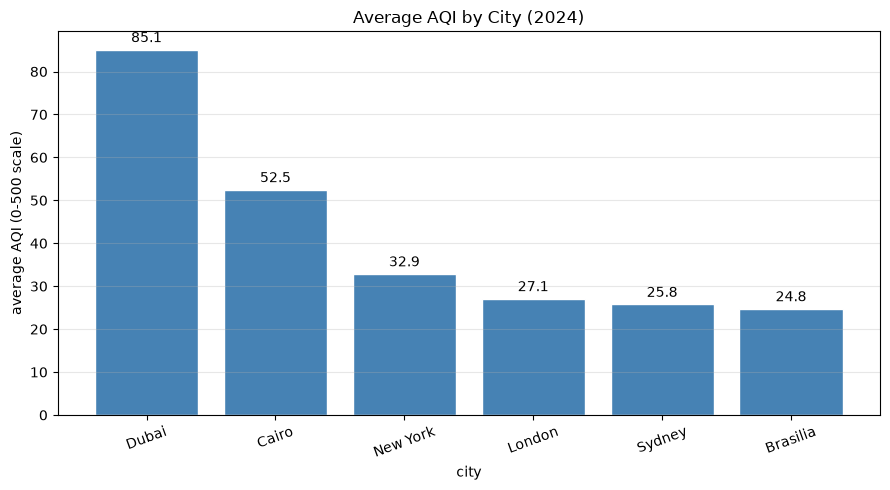

In [27]:
m08 = fresh_import("m08_visualization")

m08.plot_avg_aqi_by_city(city_summary_df)

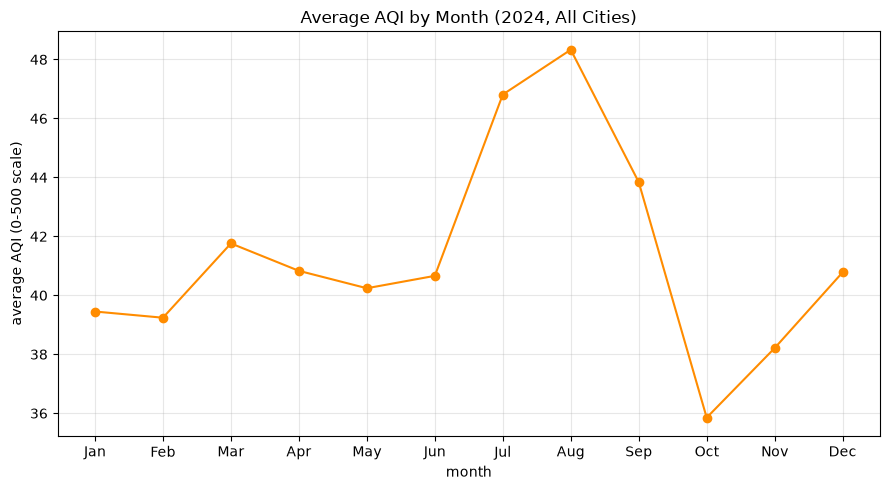

In [28]:
m08.plot_monthly_trend(monthly_summary_series)

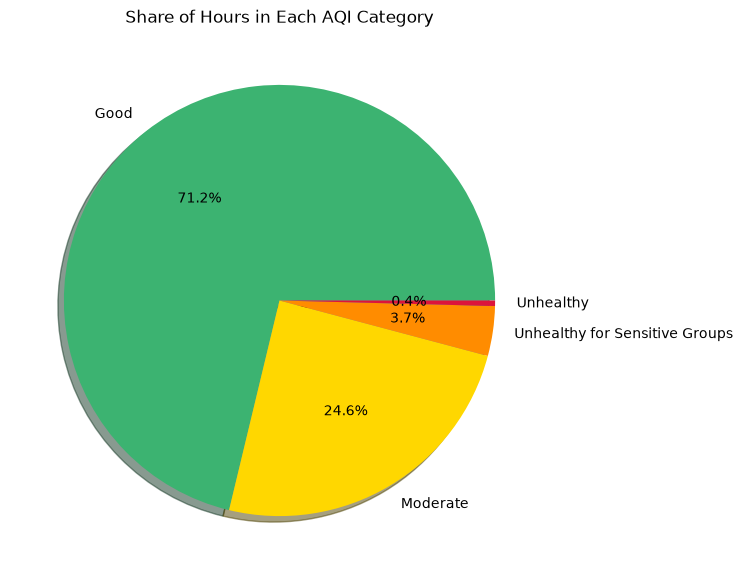

In [29]:
category_counts = df_clean["AQI Category"].value_counts()
m08.plot_category_pie(category_counts)

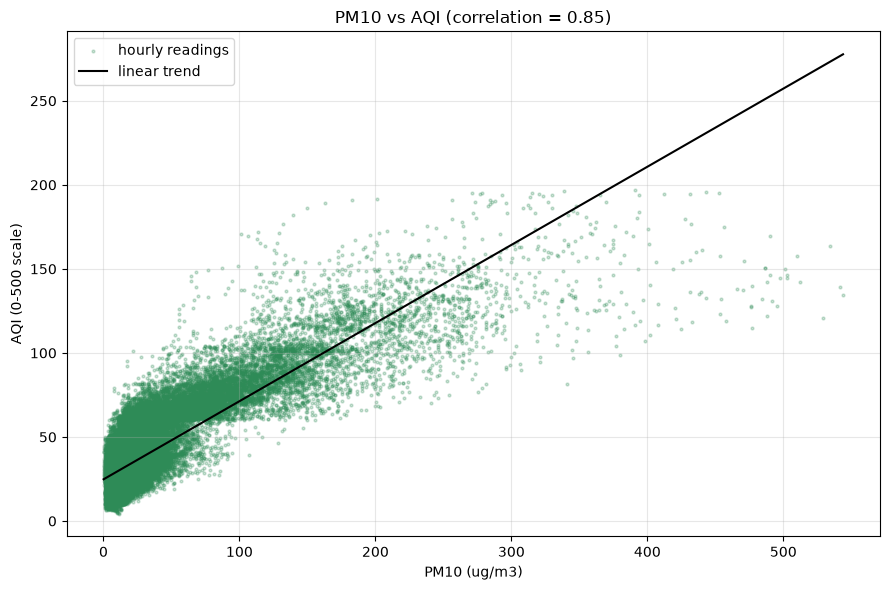

In [30]:
m08.plot_pm10_vs_aqi(df_clean, pollutant_corr["PM10"])

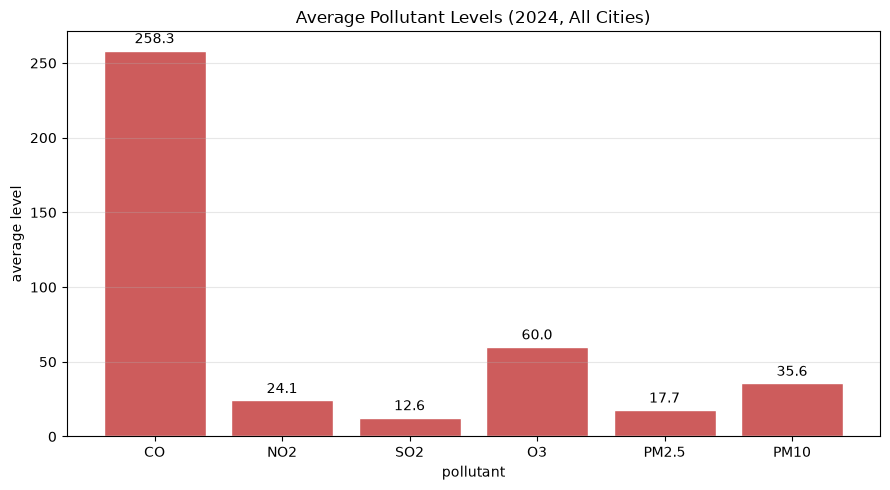

In [31]:
m08.plot_overall_pollutants(df_clean)

## Module 9: conclusion

**Finding the story in the numbers.** `major_findings()` takes the real tables built in
Module 7 and formats every number into a sentence live — nothing here is a hardcoded string,
so if the underlying data ever changes, these findings update automatically.

In [32]:
%%writefile m09_conclusion.py
"""Module 9: conclusion - findings generated live from the real numbers Module 7 produced.

No number in this module is hardcoded. Every finding is formatted from whatever the
city_summary / monthly_summary / correlation tables actually contain when this runs.
"""


def major_findings(city_summary_df, monthly_series, high_aqi_count, total_rows,
                    worst_event_city, worst_event_date, corr_series, co2_info):
    worst_city = city_summary_df.index[0]
    worst_aqi = city_summary_df["AQI"].iloc[0]
    best_city = city_summary_df.index[-1]
    best_aqi = city_summary_df["AQI"].iloc[-1]

    peak_month = int(monthly_series.idxmax())
    peak_value = monthly_series.max()
    low_month = int(monthly_series.idxmin())
    low_value = monthly_series.min()

    top_pollutant = corr_series.index[0]
    top_corr = corr_series.iloc[0]

    lines = [
        f"1. {worst_city} has the worst average air quality in this dataset (AQI {worst_aqi}); "
        f"{best_city} has the best (AQI {best_aqi}).",

        f"2. AQI peaks in month {peak_month} (avg {peak_value}) and is lowest in month "
        f"{low_month} (avg {low_value}).",

        f"3. {high_aqi_count} of {total_rows} hours ({high_aqi_count / total_rows * 100:.2f}%) "
        f"exceed AQI 100; the single worst hours are concentrated in {worst_event_city} "
        f"around {worst_event_date}.",

        f"4. {top_pollutant} is the strongest numerical driver of AQI in this dataset, "
        f"correlating at r = {top_corr}.",

        f"5. CO2 is only usable from {co2_info['earliest']} to {co2_info['latest']} "
        f"({co2_info['percent_of_all']}% of all rows) -- kept out of the main year-long "
        f"comparison for that reason.",
    ]
    return "\n".join(lines)


if __name__ == "__main__":
    from m00_load_data import load_data_with_month
    from m07_pandas_numpy import (clean_data, city_summary, monthly_summary, top_high_aqi_hours,
                                   pollutant_correlations, co2_usable_window)

    df = clean_data(load_data_with_month())
    cs = city_summary(df)
    ms = monthly_summary(df)
    high_count, worst_rows = top_high_aqi_hours(df)
    worst_city_name = worst_rows.iloc[0]["City"]
    worst_date = worst_rows.iloc[0]["Date"]
    corr = pollutant_correlations(df)
    co2 = co2_usable_window(df)

    print(major_findings(cs, ms, high_count, len(df), worst_city_name, worst_date, corr, co2))


Overwriting m09_conclusion.py


In [33]:
m09 = fresh_import("m09_conclusion")

worst_event_city = worst_hours_df.iloc[0]["City"]
worst_event_date = worst_hours_df.iloc[0]["Date"]

print(m09.major_findings(
    city_summary_df, monthly_summary_series, high_aqi_count, len(df_clean),
    worst_event_city, worst_event_date, pollutant_corr, co2_info,
))

1. Dubai has the worst average air quality in this dataset (AQI 85.11); Brasilia has the best (AQI 24.75).
2. AQI peaks in month 8 (avg 48.33) and is lowest in month 10 (avg 35.85).
3. 2182 of 52704 hours (4.14%) exceed AQI 100; the single worst hours are concentrated in Dubai around 2024-08-18 04:00:00+00:00.
4. PM10 is the strongest numerical driver of AQI in this dataset, correlating at r = 0.846.
5. CO2 is only usable from 2024-10-26 00:00:00+00:00 to 2024-12-31 23:00:00+00:00 (18.3% of all rows) -- kept out of the main year-long comparison for that reason.


## Limitations

* The dataset is a **one-year snapshot** (2024 only), so these modules cannot show whether the
  city ranking or the seasonal pattern repeats in other years.
* `CO2` is only usable for the window reported by `co2_usable_window()` above; any CO2-based
  conclusion is scoped to that window, not the full year.
* Because this is observational data, every relationship these modules compute (city
  differences, seasonal swings, pollutant correlations) is an **association**, not a proven
  cause.